#### Sentiment Analysis on Amazon Reviews

In [3]:
# install the missing wordcloud package
!pip install wordcloud

  Using cached wordcloud-1.9.4-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.4-cp313-cp313-win_amd64.whl (300 kB)


In [5]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS 
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# load the dataset
df = pd.read_csv("amazonreviews.tsv", sep='\t')

In [7]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


##### Data Cleaning

In [8]:
# check for missing va;ues
df.isnull().sum()

label     0
review    0
dtype: int64

In [11]:
# check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [12]:
# remove missing or duplicate entries
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [13]:
# text cleaning function
def clean_text(text):
    text = text.lower()                               # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)              # Remove punctuation & numbers
    text = ' '.join([word for word in text.split() 
                     if word not in stopwords.words('english')])  # Remove stopwords
    return text

df['clean_review'] = df['review'].apply(clean_text)
print("\nSample cleaned text:")
print(df['clean_review'].head())


Sample cleaned text:
0    stuning even nongamer sound track beautiful pa...
1    best soundtrack ever anything im reading lot r...
2    amazing soundtrack favorite music time hands i...
3    excellent soundtrack truly like soundtrack enj...
4    remember pull jaw floor hearing youve played g...
Name: clean_review, dtype: object


##### Exploratory Data Analysis

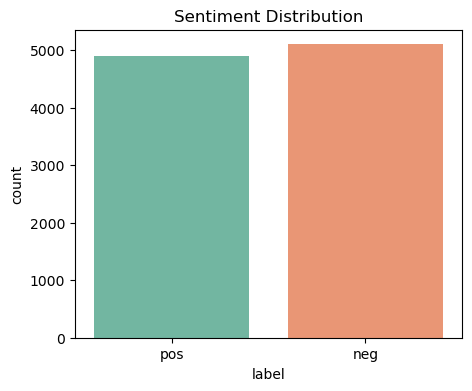

In [15]:
# sentiment distribution
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Sentiment Distribution')
plt.show()

In [16]:
# WordClouds for positive and negative reviews
pos_text = ' '.join(df[df['label']=='pos']['clean_review'])
neg_text = ' '.join(df[df['label']=='neg']['clean_review'])

Text(0.5, 1.0, 'Positive Reviews WordCloud')

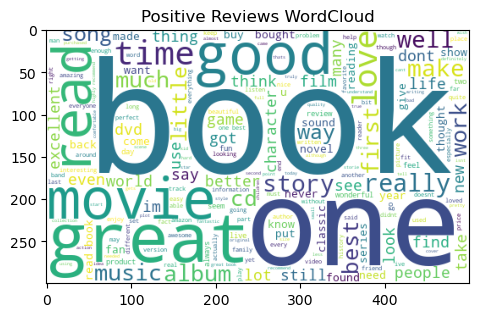

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=500, height=300, background_color='white', stopwords=STOPWORDS).generate(pos_text))
plt.title("Positive Reviews WordCloud")

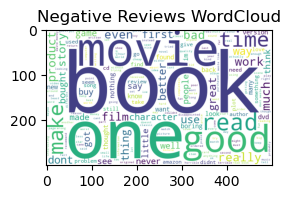

In [18]:
plt.subplot(1,2,2)
plt.imshow(WordCloud(width=500, height=300, background_color='white', stopwords=STOPWORDS).generate(neg_text))
plt.title("Negative Reviews WordCloud")
plt.show()

##### Text Vectorization (TF-IDF)

In [19]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['label']

#####  Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##### Model Training (Logistic Regression)

In [21]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


##### Model Evaluation

In [22]:
y_pred = model.predict(X_test)

print("\nModel Performance Report:\n")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Model Performance Report:

              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Accuracy: 0.85


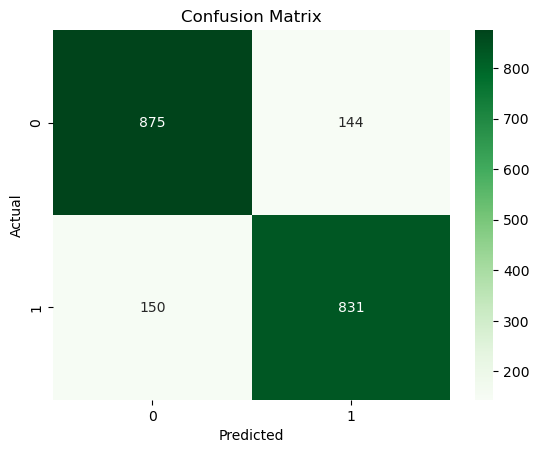

In [23]:
# confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Example Predictions

In [24]:
sample_reviews = [
    "The product quality is amazing, totally worth the money!",
    "Worst purchase ever. It broke after one use."
]
sample_clean = [clean_text(r) for r in sample_reviews]
sample_vec = tfidf.transform(sample_clean)
preds = model.predict(sample_vec)

for review, sentiment in zip(sample_reviews, preds):
    print(f"Review: {review}\nPredicted Sentiment: {sentiment}\n")

Review: The product quality is amazing, totally worth the money!
Predicted Sentiment: neg

Review: Worst purchase ever. It broke after one use.
Predicted Sentiment: neg



                           Submitted by: Meghana C Varghese